In [1]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
import scvi
from scipy.sparse import csr_matrix
import numpy as np

/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
# scVI settings
scvi.settings.seed = 1212
scvi.settings.dl_num_workers = 5
print("Last run with scvi-tools version:", scvi.__version__)

[rank: 0] Seed set to 1212


Last run with scvi-tools version: 1.3.0


In [3]:
# Path to data files
print('Current working directory set to:', os.getcwd())

atlas_key = 'combined_reference'  # including Mayassi 2024, Drokhlyansky 2020, Gu 2024, Gomez-Vazquez (unpublished) and Sirvinskas 2022
atlasPath = '/users/sansom/tme871/work/cosmx_mouse/IBD_mouse_scRNA-seq_atlas/data/combined_feature-subset.h5ad'

query_key = 'mouse_ibd_hh_atomx'
queryPath = '/users/sansom/tme871/work/cosmx_mouse/spatialhub/anndata.dir/mouse_ibd_hh_atomx_filtered.h5ad'  # moving on to full dataset, filtered for low-quality cells/samples

# Path to out files
modelDir = os.path.join('/users/sansom/tme871/work/cosmx_mouse/spatialhub/annotation', 'scANVI_' + atlas_key)
print('scVI output will be saved to:', modelDir)
if not os.path.exists(modelDir):
    os.mkdir(modelDir)

Current working directory set to: /gpfs3/well/sansom/users/tme871/work/cosmx_mouse/spatialhub/annotation
scVI output will be saved to: /users/sansom/tme871/work/cosmx_mouse/spatialhub/annotation/scANVI_combined_reference


In [4]:
# scVI parameters
scvi_batch = 'dataset'
scvi_categorical = ['inflamed', 'tissue', 'sample_name']  # adding 'tech_chem' as covariate seemed to make annotations messier rather than better
scvi_continuous = None

# label_key to use for annotation
scvi_label = 'Lineage_HiRes'
scanvi_preds_key = 'predicted_' + scvi_label

In [5]:
# [OPTIONAL] Plotting parameters
sc.settings.figdir = modelDir
plot_covar = [scvi_batch] + ['mouse', 'inflamed', 'condition', 'exp_batch', 'sample_name', 'tech_chem', 'tissue']
plot_annot = [scvi_label] + ['Lineage_LoRes', 'harmonized_annot',
                             #'original_annot'  # too many to visualize!
                            ]

# Model-specific parameters to append to files names when saving figures
model_params = '_BATCH_dataset_COVAR_inflamed_tissue_sample-name_'

## Re-load query dataset

In [6]:
# Load query AnnData
print("Importing query " + queryPath)
sdata = sc.read_h5ad(queryPath)
print("Predicting cell types for the following query dataset", sdata)

Importing query /users/sansom/tme871/work/cosmx_mouse/spatialhub/anndata.dir/mouse_ibd_hh_atomx_filtered.h5ad
Predicting cell types for the following query dataset AnnData object with n_obs × n_vars = 922473 × 974
    obs: 'slide_id', 'fov', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.CD298.B2M', 'Max.CD298.B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'unassignedTranscripts', 'nCount_neg', 'nCount_sys', 'nCount_ucc', 'nFeature_ucc', 'nCount_add', 'nFeature_add', 'nCount_RNA', 'nFeature_RNA', 'percentNegCounts', 'complexity', 'nCount_rand20', 'qcFlagCell_nCount', 'qcFlagCell_nFeature', 'qcFlagCell_percentNeg', 'qcFlagCell_complex', 'qcFlagCell_summary', 'slide_name', 'sample_id', 'sample_name', 'tissue', 'condition', 'batch', 'sample_index', 'nCount_RNA_sampleSum', 'nCount_neg_sampleSum', 'nCount_sys_sampleSum', 'nCell_sampleSum', 'nCount_RNA_sampleAvg', 'nFeature_RNA_sampleAvg',

In [7]:
# Convert matrix to CSR float32 to speed up scVI/normalization
if 'counts' in sdata.layers.keys():
  print("'counts' layer already stored in input reference dataset. Converting to CSR array.")
  sdata.layers['counts'] = csr_matrix(sdata.layers['counts'].copy(), dtype = "float32")
else:  # in this case, we'll assume counts are in X slot (but worth a manual check!)
  print("WARNING: no 'counts' layer stored in input reference dataset. Assuming sdata.X slot is set to 'counts'")
  sdata.layers['counts'] = csr_matrix(sdata.X.copy(), dtype = "float32")

In [8]:
sdata.var.index

Index(['Aatk', 'Abl1', 'Abl2', 'Acacb', 'Ace', 'Ackr1', 'Ackr3', 'Ackr4',
       'Acta2', 'Actg2',
       ...
       'Wnt7a', 'Wnt7b', 'Wnt9a', 'Xbp1', 'Xcl1', 'Xkr4', 'Yap', 'Ybx3',
       'Yes1', 'Zfp36'],
      dtype='object', length=974)

In [9]:
# As a reminder, these variables were used to train our scVI model
print("batch_key:", scvi_batch)
print("categorical covariates:", scvi_categorical)

batch_key: dataset
categorical covariates: ['inflamed', 'tissue', 'sample_name']


## Assess validity of cell type annotation

In [10]:
# Load cell-type annotation metadata
df = pd.read_csv(os.path.join(modelDir, 
                              query_key + '_metadata_scANVI_' + atlas_key + '_' + scvi_label + '.csv'))

df.rename(columns = {df.columns[0]: "index"}, inplace = True)
df.index = df.iloc[:,0]
df.drop(df.columns[0], axis=1, inplace = True)
#df

# Append it to sdata object
if sdata.obs.index.equals(df.index):
    sdata.obs = df

sdata.obs

,slide_id,fov,CenterX_global_px,CenterY_global_px,Area,AspectRatio,Width,Height,Mean.PanCK,Max.PanCK,...,block,dataset,tech_chem,inflamed,segment,biological_sample,_scvi_batch,Lineage_HiRes,_scvi_labels,predicted_Lineage_HiRes
index,,,,,,,,,,,,,,,,,,,,,
FOV1_C3_NL4S3a,NL4S3a,1,5198,135669,8200,0.83,99,119,561,2516,...,old,CosMx study,spatial_cosmx,0,colon_distal,SS_dist1,5,unknown,18,Mural/other structural cells
FOV1_C4_NL4S3a,NL4S3a,1,5083,135653,12866,1.19,146,123,530,1724,...,old,CosMx study,spatial_cosmx,0,colon_distal,SS_dist1,5,unknown,18,Endothelial cells
FOV1_C5_NL4S3a,NL4S3a,1,5275,135636,10302,1.12,126,113,480,2976,...,old,CosMx study,spatial_cosmx,0,colon_distal,SS_dist1,5,unknown,18,Endothelial cells
FOV1_C6_NL4S3a,NL4S3a,1,5166,135598,7295,0.97,107,110,602,4292,...,old,CosMx study,spatial_cosmx,0,colon_distal,SS_dist1,5,unknown,18,Endothelial cells
FOV1_C7_NL4S3a,NL4S3a,1,5556,135548,14135,1.15,148,129,447,2044,...,old,CosMx study,spatial_cosmx,0,colon_distal,SS_dist1,5,unknown,18,Endothelial cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FOV284_C1428_NL5H1b,NL5H1b,284,93313,-1751,3608,0.93,67,62,652,1340,...,old,CosMx study,spatial_cosmx,0,colon_proximal,D04_prox3,5,unknown,18,Mural/other structural cells
FOV284_C1432_NL5H1b,NL5H1b,284,93638,-1764,4690,0.92,78,72,721,1316,...,old,CosMx study,spatial_cosmx,0,colon_proximal,D04_prox3,5,unknown,18,Mural/other structural cells
FOV284_C1434_NL5H1b,NL5H1b,284,94770,-1803,9990,0.99,118,117,756,1340,...,old,CosMx study,spatial_cosmx,0,colon_proximal,D04_prox3,5,unknown,18,Mesothelial cells


In [11]:
# Normalize sdata for marker selection
sc.pp.normalize_total(sdata, exclude_highly_expressed=True, max_fraction=0.2)
sdata.layers['norm'] = sdata.X.copy()
#sdata.write_h5ad('/users/sansom/tme871/work/cosmx_mouse/spatialhub/anndata.dir/mouse_ibd_hh_atomx_normalized.h5ad')

/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [12]:
## Dropping category which only includes one cell, if applicable (may happen at piloting stage)
#sdata = sdata[sdata.obs[scanvi_preds_key] != 'Mast cells']

# Updating categories
sdata.obs[scanvi_preds_key] = sdata.obs[scanvi_preds_key].astype(str).astype('category')
print(sdata.obs[scanvi_preds_key])

index
FOV1_C3_NL4S3a         Mural/other structural cells
FOV1_C4_NL4S3a                    Endothelial cells
FOV1_C5_NL4S3a                    Endothelial cells
FOV1_C6_NL4S3a                    Endothelial cells
FOV1_C7_NL4S3a                    Endothelial cells
                                   ...             
FOV284_C1428_NL5H1b    Mural/other structural cells
FOV284_C1432_NL5H1b    Mural/other structural cells
FOV284_C1434_NL5H1b               Mesothelial cells
FOV284_C1437_NL5H1b               Endothelial cells
FOV284_C1438_NL5H1b               Endothelial cells
Name: predicted_Lineage_HiRes, Length: 922473, dtype: category
Categories (18, object): ['B lymphocytes', 'Cycling Enterocytes', 'Cycling Goblet cells', 'Dendritic cells', ..., 'Mural/other structural cells', 'Neutrophils', 'T lymphocytes/NK/ILCs', 'Tuft cells']


In [13]:
# Obtain cell type-specific markers
sc.tl.rank_genes_groups(sdata, 
                        layer = 'norm',
                        groupby = scanvi_preds_key, 
                        method = 't-test',
                        pts = True)

# Save to CSV
sc.get.rank_genes_groups_df(sdata, group=None).to_csv(
    os.path.join(modelDir,
                 query_key + '_' + atlas_key + '_' + scvi_label +  '_top-markers.csv')
)

/users/sansom/tme871/devel/venvs/python-3.10.8-GCCcore-12.2.0-skylake-cgat-spatial/lib/python3.10/site-packages/scanpy/tools/_utils.py:40: UserWarning: You’re trying to run this on 974 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


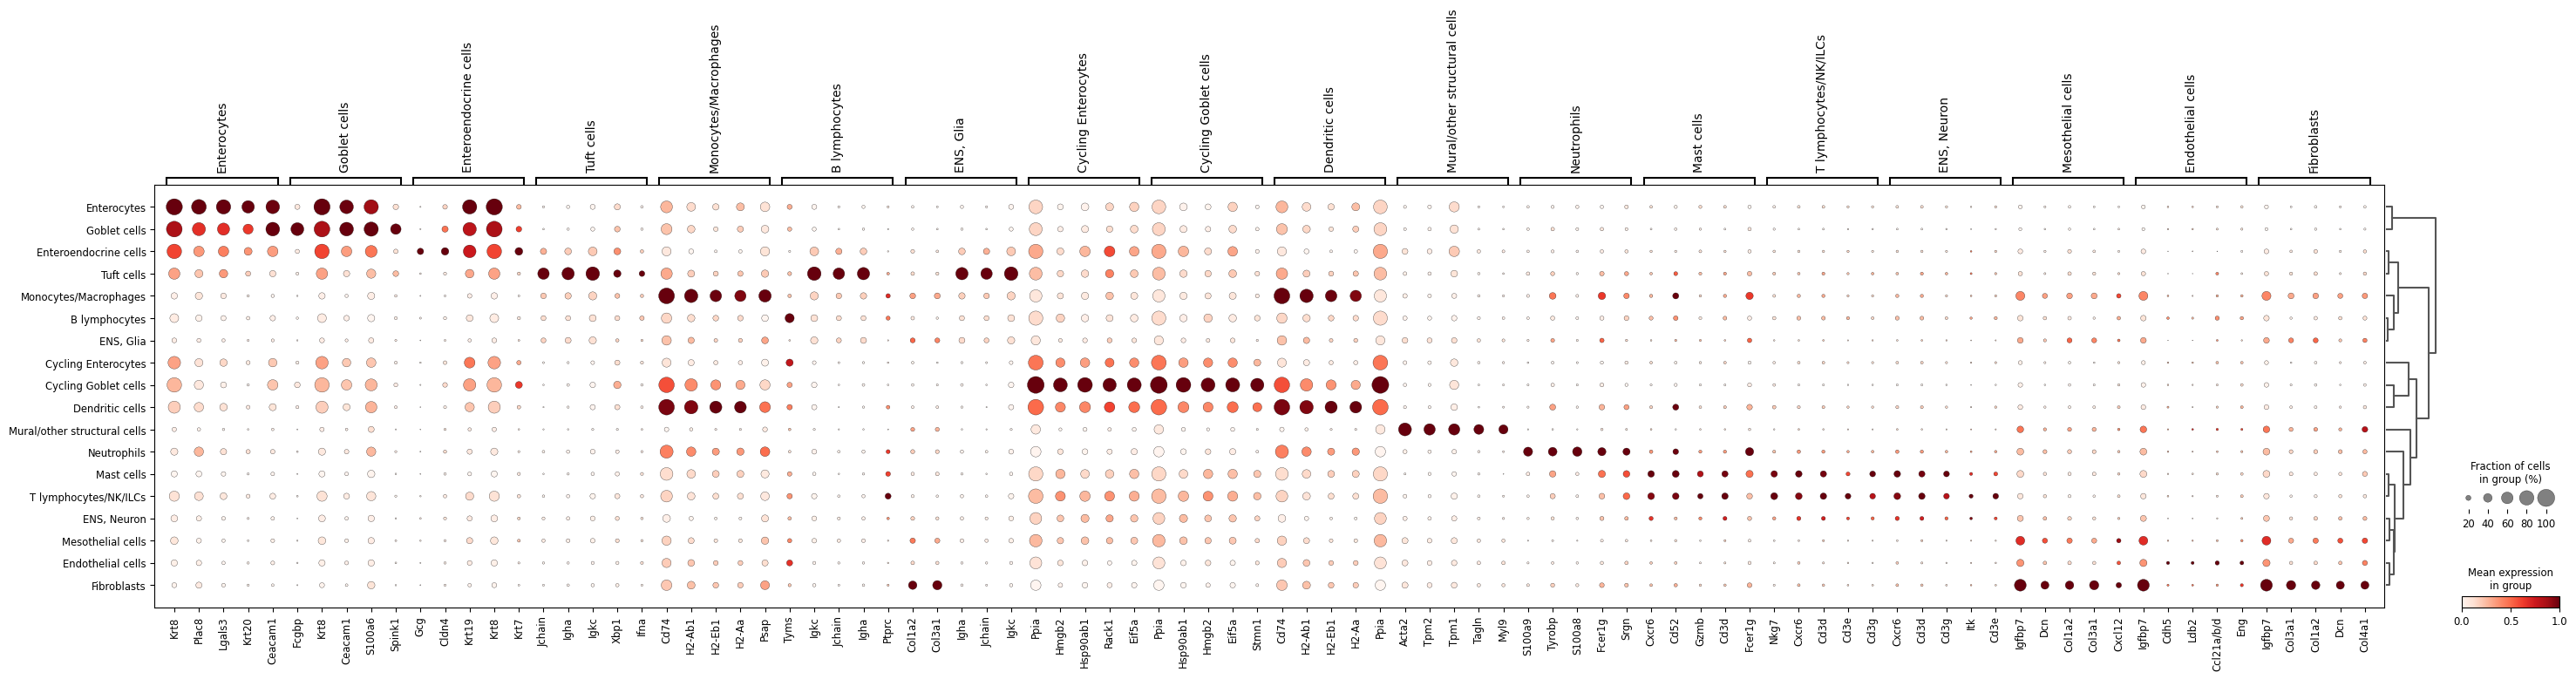

In [14]:
# Generate dot plot of top markers
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    layer = 'norm',
    groupby=scanvi_preds_key,
    standard_scale="var", 
    n_genes=5,
    save = query_key + '_' + atlas_key + '_' + scvi_label + '_top-markers.pdf'
)

In [15]:
# Custom dotplot, looking at specific marker genes from the literature/atlas
marker_genes_dict = {
    "Proliferation": ['Mki67'],

    "Pan-epithelial": ['Epcam', 
                       'Ceacam1', # may be found on immune cells as well
                       'Cdh1',
                       'Mecom',
                       'Krt8'
                      ],
    "(Cycling) Enterocytes": ['Lgr5', 'Ephb2', 'Arid5b', 'Krt20', 
                              #'Saa1'
                             ],
    "(Cycling) Goblet": ['Krt18', # also on Tuft
                         'Krt7', 'Fcgbp', 'Agr2', 'Muc1'],
    #"Tuft": ['Fyb', 'Hck'] # markers also found on some immune cells!!
    "Enteroendocrine": ['Rack1', 'Reg4', 'Gcg'],
    "Mesothelial": ['Dcn', 'Col3a1', # both also on Fib...
                    'Efna5', 'Meg3', 'Cav1'], 
    
    #"Epithelial cells": [#'Krt20', # Enterocytes & Goblet
                         #'Krt8', 
                         #'Ceacam1', 'Plac8'  # The latter two may be seen on epithelial as well as immune cells
                         #'Krt7', 'Fcgbp', 'Agr2',  # Goblet
                         #'Muc1', 'S100a6',  # Goblet (mostly)
                         #'Epcam',  # EECs and Tuft
                         #'Rack1', 'Reg4', 'Gcg',  # EECs
                         #'Lgr5'],  # Stem
   
    "Pan-immune": ['Ptprc', 'Cd52', 'Cd53', 'Cd74', 'H2-Ab1'],
    #"APCs": ["Cd74", "H2-Eb1", "H2-Ab1", "H2-Aa"],
    "B": ['Cd79a', 'Cd19', 'Ms4a1', 'Mzb1', 'Cd37', 'Ighm', 'Igkc', 'Jchain'],
    "T": ["Cd3d", "Cd3e", "Cd3g", 
          'Hcst', # T and NK both
          'Rgs2', # may also be found on neurons/SMCs!!
          'Cd4', 'Cd40lg', 'Cd8a', 'Cd8b1'],
    "NK/ILC": ['Prf1', 'Nkg7', 'Klrb1'],

    "Myeloid": ['Itgam', 'Itgax', 'Cd68',  # mono, mac and DCs
                'S100a8', 'S100a9', 'Cst7', 'SiglecF (170)',  # mostly, Neutrophils and Macrophages
                'Cx3cr1', 'Csf1r',  # mono and DCs
                'Tyrobp', # could also be on microglia
                'Cd14', 'Crip1', 'Cd300a'],  # mono and mac
    "Neutrophil": [#"Elane", 
                   "Mpo", "Ly6G", "Cd177", "Ltf"],
    "Mono": ['Ly6c2', 'Vcan', 'Ccr2', 'Cd177',  # expected in Ly6c+ mono
             'Ace', 'Cd9', 'Apoe'],  # expected in Ly6c- mono
    "Mac": ["Cd64", "C1qb", "C1qc", "Mrc1", "Mertk"],  # "Lyve1" => also found on Endothelial Cells
    "Mast cells": ['Cpa3', "Kit", 'Fcer1g'],
    "DC": ["Tap1", "Cd209a", "Cd209e"],

    "Pan-stromal": ['Col3a1', 'Cald1', 'Igfbp7', 'Col4a1', 'Fn1'],
    "Endothelial": ["Pecam1", "Ccl21a/b/d", 
                    #"Col4a1",  # also Fib
                    "Fabp4", "Cdh5", "Vim",
                    'Flt1'],
    "Fibroblast": [#"Col3a1", "Dcn",  # also on mesothelial
                   "Col1a1", "Col1a2",
                   "Col6a1", "Col6a2",
                   'Cxcl12', 'Ccl11'],
    "Mural/SMC/Myofib" : ["Acta2", "Actg2", "Tpm1", "Tpm2", "Myl9", "Tagln", "Rgs5"],
    "Neuron": ['Nrxn1', 'Dst']
    #"Mural/Goblet/ENS": ['Dll1', 'Dll4', 'Ido1']  # drawn from Mayassi 2024 custom panel

}

categories: B lymphocytes, Cycling Enterocytes, Cycling Goblet cells, etc.
var_group_labels: Proliferation, Pan-epithelial, (Cycling) Enterocytes, etc.


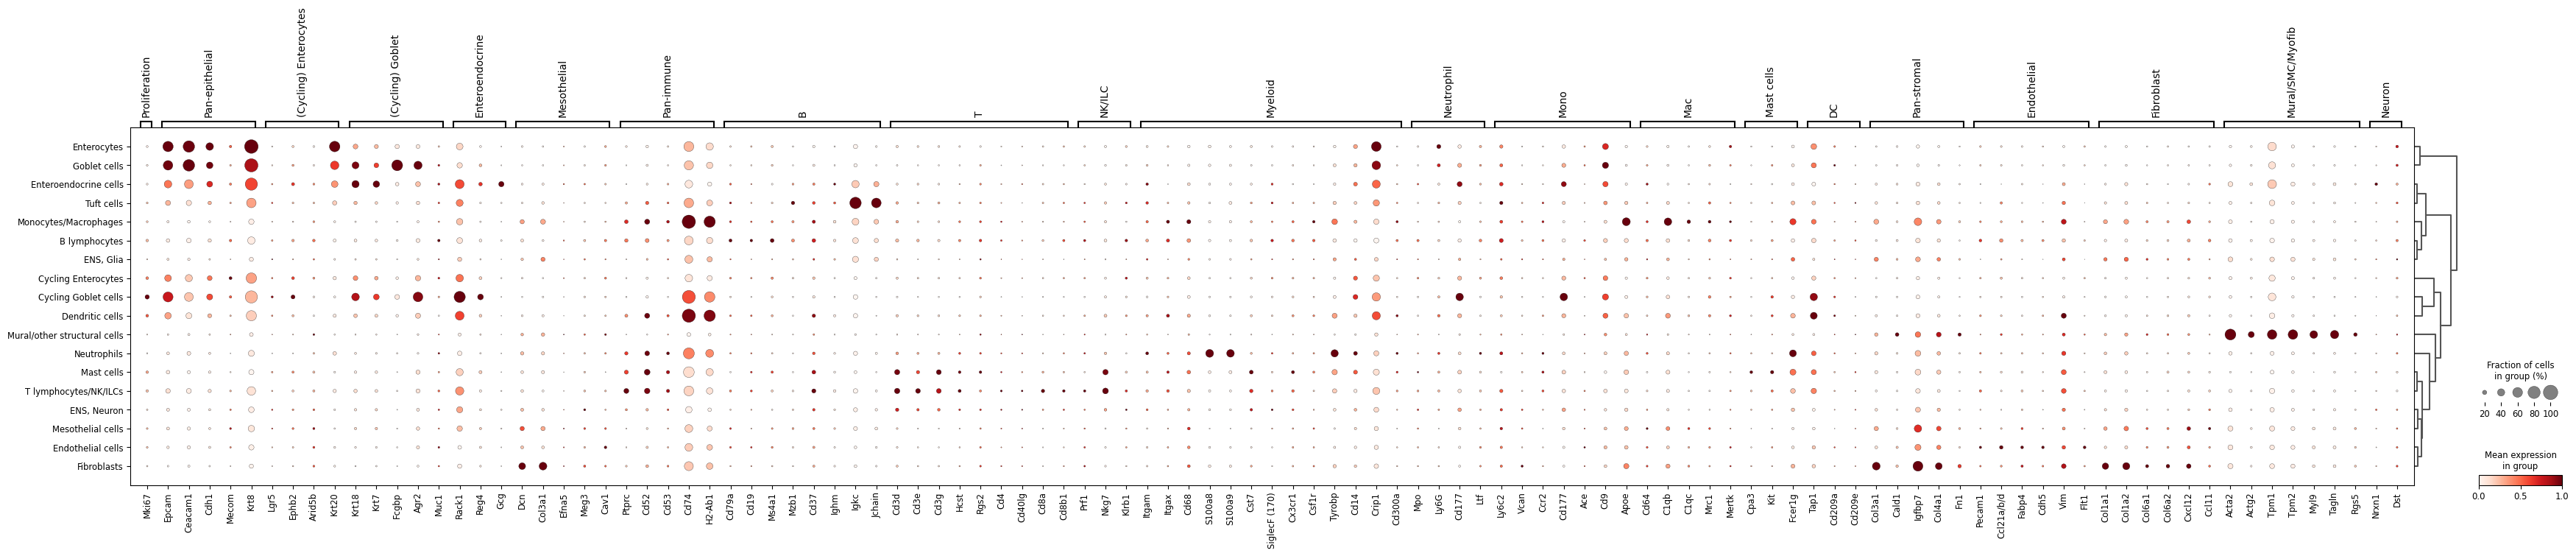

In [17]:
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    var_names = marker_genes_dict,
    layer = 'norm',
    groupby = scanvi_preds_key,
    standard_scale = "var",
    save = query_key + '_' + atlas_key + '_' + scvi_label + '_known-markers.pdf'
)

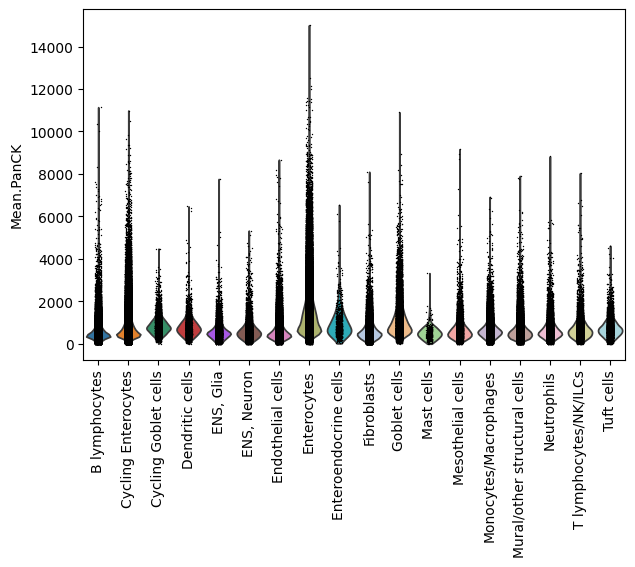

In [18]:
sc.pl.violin(sdata, 
             keys=['Mean.PanCK'], 
             groupby=scanvi_preds_key, 
             rotation=90)

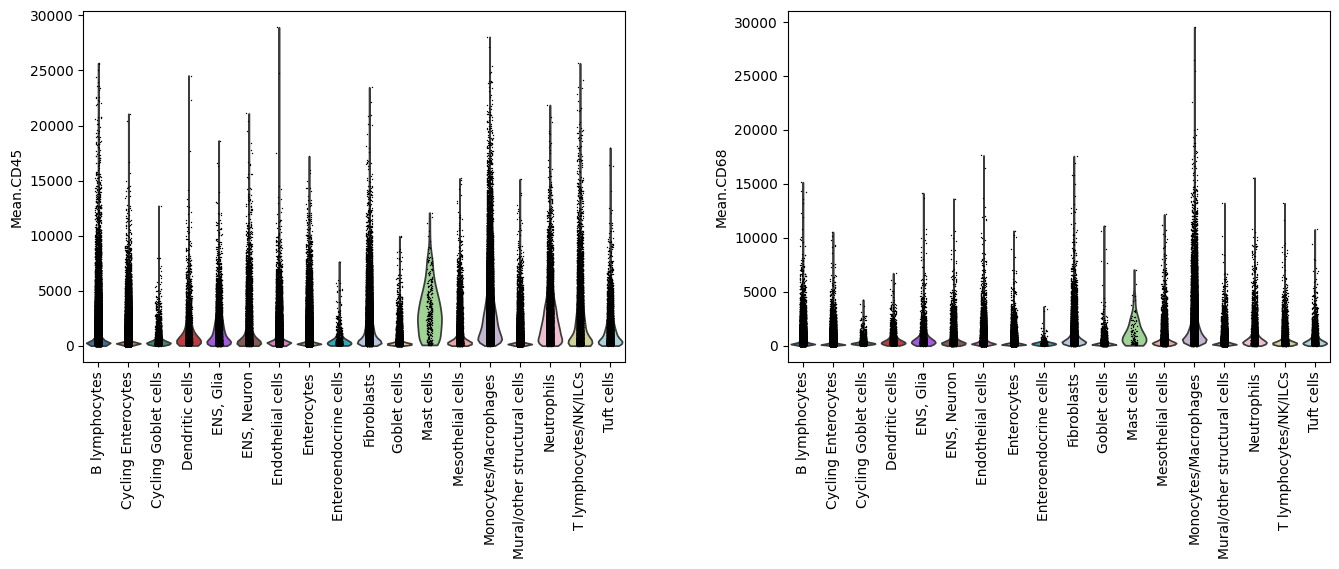

In [19]:
sc.pl.violin(sdata, 
             keys=['Mean.CD45', 'Mean.CD68'], 
             groupby=scanvi_preds_key, 
             rotation=90)

In [22]:
# Improving readability of dotplot
adata = sc.read_h5ad(atlasPath)
print(scanvi_preds_key)
epi_subsets = adata.obs['Lineage_HiRes'][adata.obs['Lineage_LoRes'] == 'Epithelial cells'].unique()
imm_subsets = adata.obs['Lineage_HiRes'][adata.obs['Lineage_LoRes'] == 'Immune cells'].unique()
str_subsets = adata.obs['Lineage_HiRes'][adata.obs['Lineage_LoRes'] == 'Stromal cells'].unique()

predicted_Lineage_HiRes


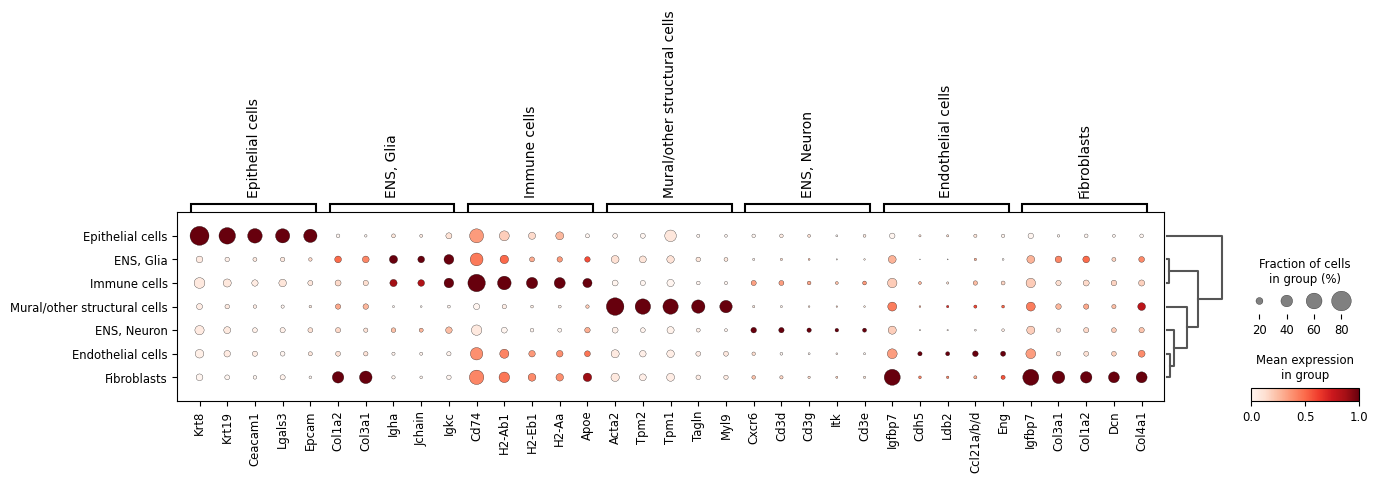

In [23]:
# Dotplot 1: Focus on stromal subsets

sdata.obs['str_harmonized_annot'] = sdata.obs[scanvi_preds_key].astype(str).copy()
sdata.obs.loc[sdata.obs['str_harmonized_annot'].isin(imm_subsets), 'str_harmonized_annot'] = 'Immune cells'
sdata.obs.loc[sdata.obs['str_harmonized_annot'].isin(epi_subsets), 'str_harmonized_annot'] = 'Epithelial cells'
sdata.obs['str_harmonized_annot'] = sdata.obs['str_harmonized_annot'].astype('category')

sc.tl.rank_genes_groups(sdata, 
                        layer = 'norm',
                        groupby = 'str_harmonized_annot', 
                        method = 't-test',
                        pts = True)

sc.tl.dendrogram(sdata, groupby = 'str_harmonized_annot')
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    layer = 'norm',
    groupby = 'str_harmonized_annot',
    standard_scale = "var", 
    n_genes = 5,
    #save = query_key + '_' + atlas_key + '_' + scvi_label + '_top-markers_str.pdf'
)

categories: ENS, Glia, ENS, Neuron, Endothelial cells, etc.
var_group_labels: Proliferation, Pan-epithelial, (Cycling) Enterocytes, etc.


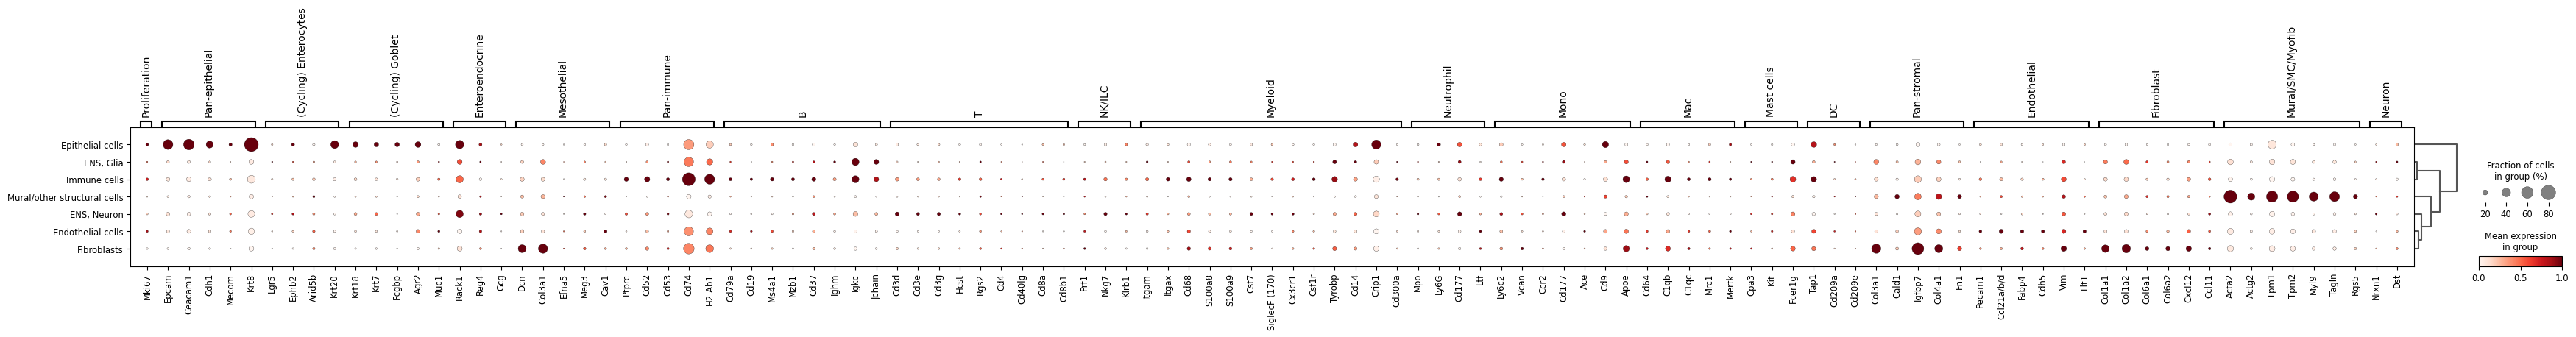

In [24]:
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    var_names = marker_genes_dict,
    layer = 'norm',
    groupby = 'str_harmonized_annot',
    standard_scale = "var"
    #save = query_key + '_' + atlas_key + '_' + scvi_label + '_known-markers_str.pdf'
)

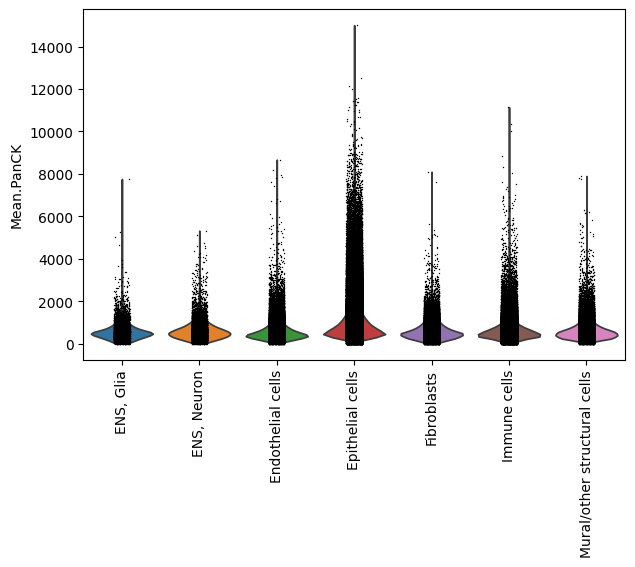

In [25]:
sc.pl.violin(sdata, 
             keys=['Mean.PanCK'], 
             groupby='str_harmonized_annot', 
             rotation=90)

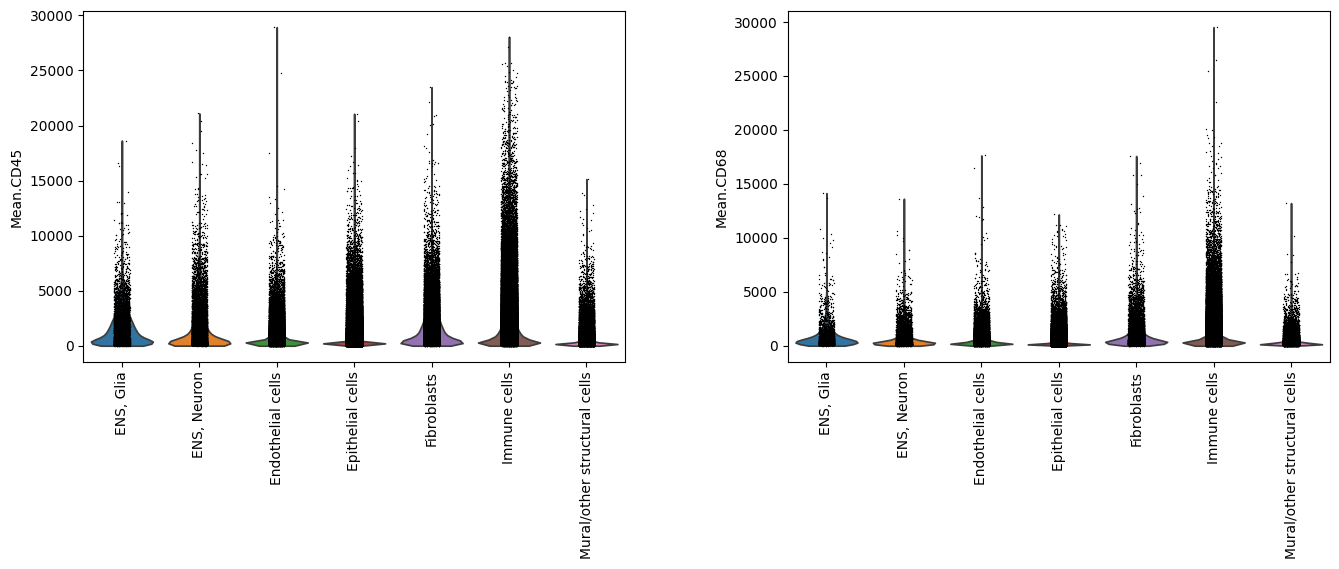

In [26]:
sc.pl.violin(sdata, 
             keys=['Mean.CD45', 'Mean.CD68'], 
             groupby='str_harmonized_annot', 
             rotation=90)

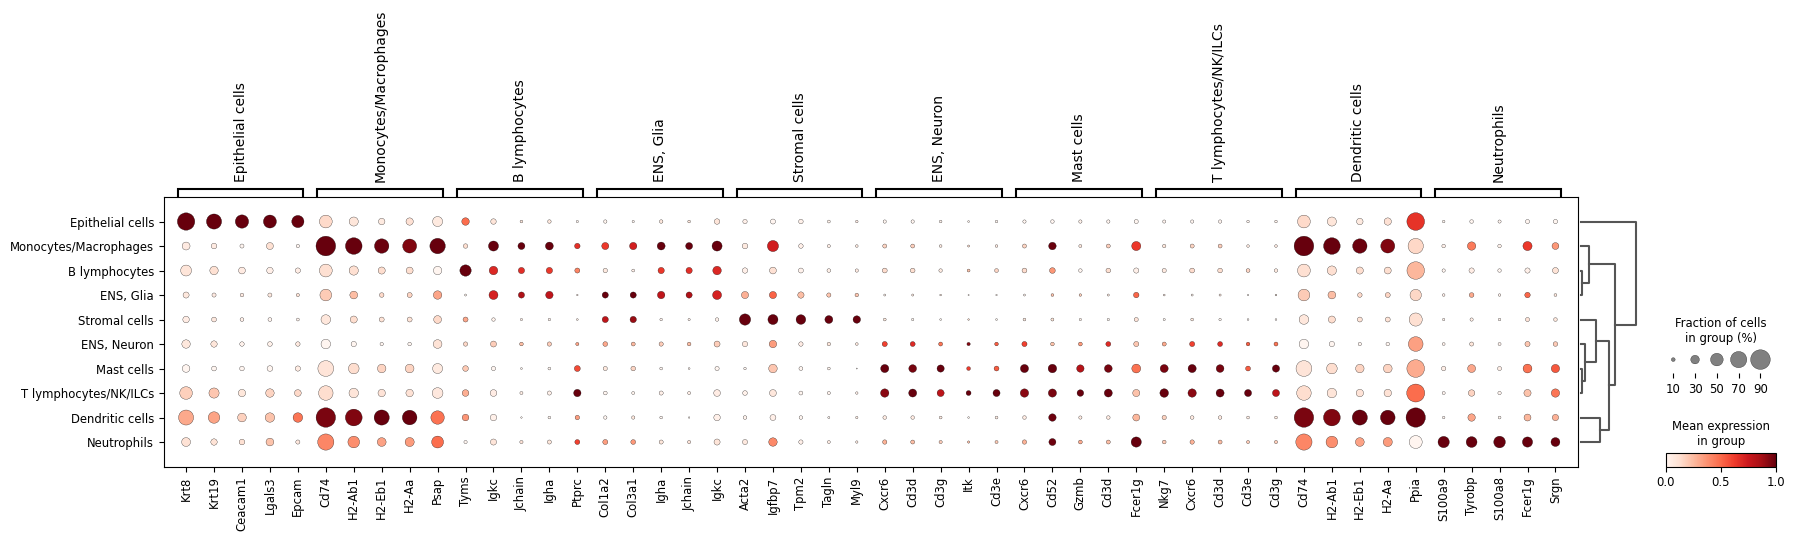

In [27]:
# Dotplot 2: Focus on immune subsets

sdata.obs['imm_harmonized_annot'] = sdata.obs[scanvi_preds_key].astype(str).copy()
sdata.obs.loc[sdata.obs['imm_harmonized_annot'].isin(str_subsets), 'imm_harmonized_annot'] = 'Stromal cells'
sdata.obs.loc[sdata.obs['imm_harmonized_annot'].isin(epi_subsets), 'imm_harmonized_annot'] = 'Epithelial cells'
sdata.obs['imm_harmonized_annot'] = sdata.obs['imm_harmonized_annot'].astype('category')

sc.tl.rank_genes_groups(sdata, 
                        layer = 'norm',
                        groupby = 'imm_harmonized_annot', 
                        method = 't-test',
                        pts = True)

sc.tl.dendrogram(sdata, groupby = 'imm_harmonized_annot')
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    layer = 'norm',
    groupby = 'imm_harmonized_annot',
    standard_scale = "var", 
    n_genes = 5,
    #save = query_key + '_' + atlas_key + '_' + scvi_label + '_top-markers_imm.pdf'
)

categories: B lymphocytes, Dendritic cells, ENS, Glia, etc.
var_group_labels: Proliferation, Pan-epithelial, (Cycling) Enterocytes, etc.


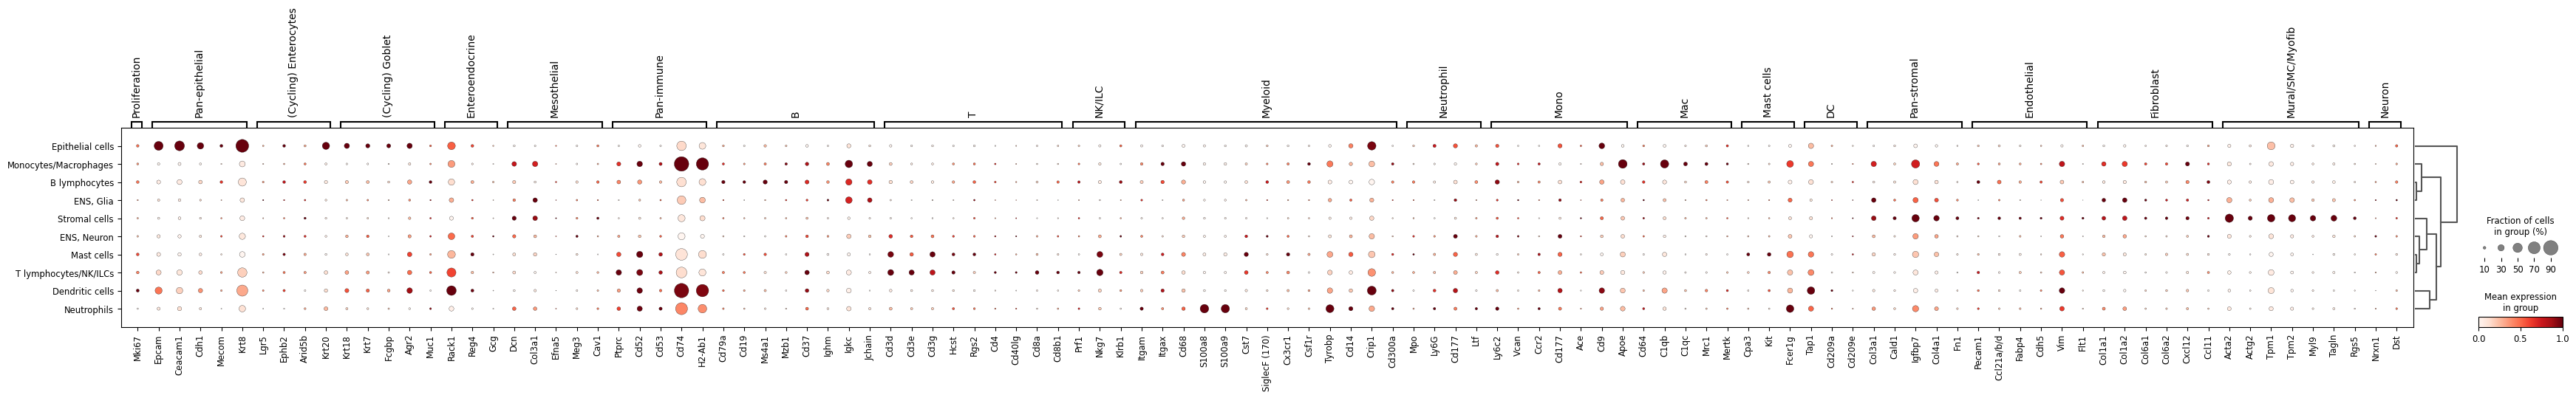

In [28]:
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    var_names = marker_genes_dict,
    layer = 'norm',
    groupby = 'imm_harmonized_annot',
    standard_scale = "var"
    #save = query_key + '_' + atlas_key + '_' + scvi_label + '_known-markers_imm.pdf'
)

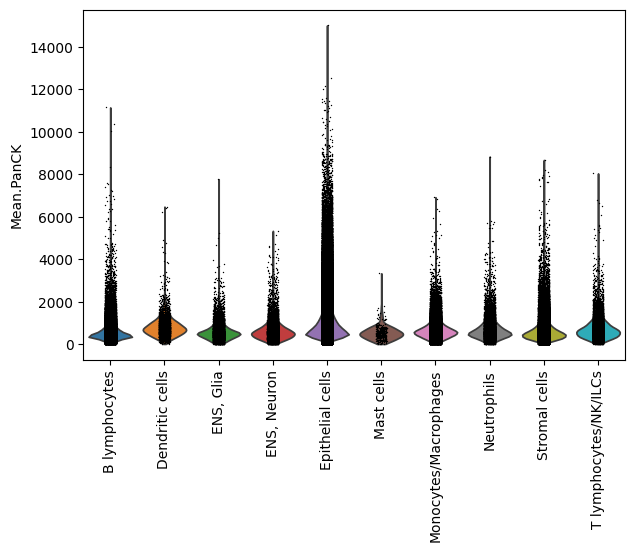

In [29]:
sc.pl.violin(sdata, 
             keys=['Mean.PanCK'], 
             groupby='imm_harmonized_annot', 
             rotation=90)

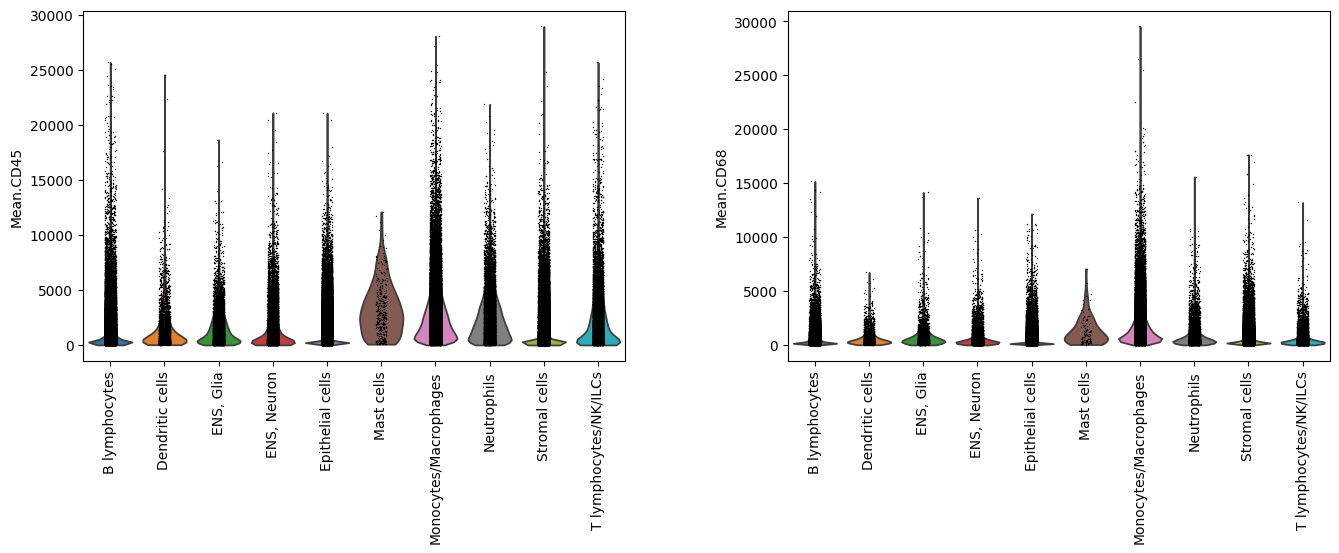

In [30]:
sc.pl.violin(sdata, 
             keys=['Mean.CD45', 'Mean.CD68'], 
             groupby='imm_harmonized_annot', 
             rotation=90)

In [31]:
# Dotplot 3: Focus on epithelial subsets (and suspected epithelial subsets, if applicable...)

sdata.obs['epi_harmonized_annot'] = sdata.obs[scanvi_preds_key].astype(str).copy()

sdata.obs.loc[sdata.obs['epi_harmonized_annot'].isin(imm_subsets), 'epi_harmonized_annot'] = 'Immune cells'
'''
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'Mono', 'epi_harmonized_annot'] = 'Mono'
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'Mono/Mac', 'epi_harmonized_annot'] = 'Mono/Mac'
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'Mac', 'epi_harmonized_annot'] = 'Mac'
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'Neutrophil', 'epi_harmonized_annot'] = 'Neutrophil'
'''

sdata.obs.loc[sdata.obs['epi_harmonized_annot'].isin(str_subsets), 'epi_harmonized_annot'] = 'Stromal cells'
'''
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'Cd81 Fib', 'epi_harmonized_annot'] = 'Cd81 Fib'
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'F3 Fib', 'epi_harmonized_annot'] = 'F3 Fib'
sdata.obs.loc[sdata.obs[scanvi_preds_key] == 'Tcf21 Fib', 'epi_harmonized_annot'] = 'Tcf21 Fib'
'''

sdata.obs['epi_harmonized_annot'] = sdata.obs['epi_harmonized_annot'].astype('category')
#print(sdata.obs['epi_harmonized_annot'])

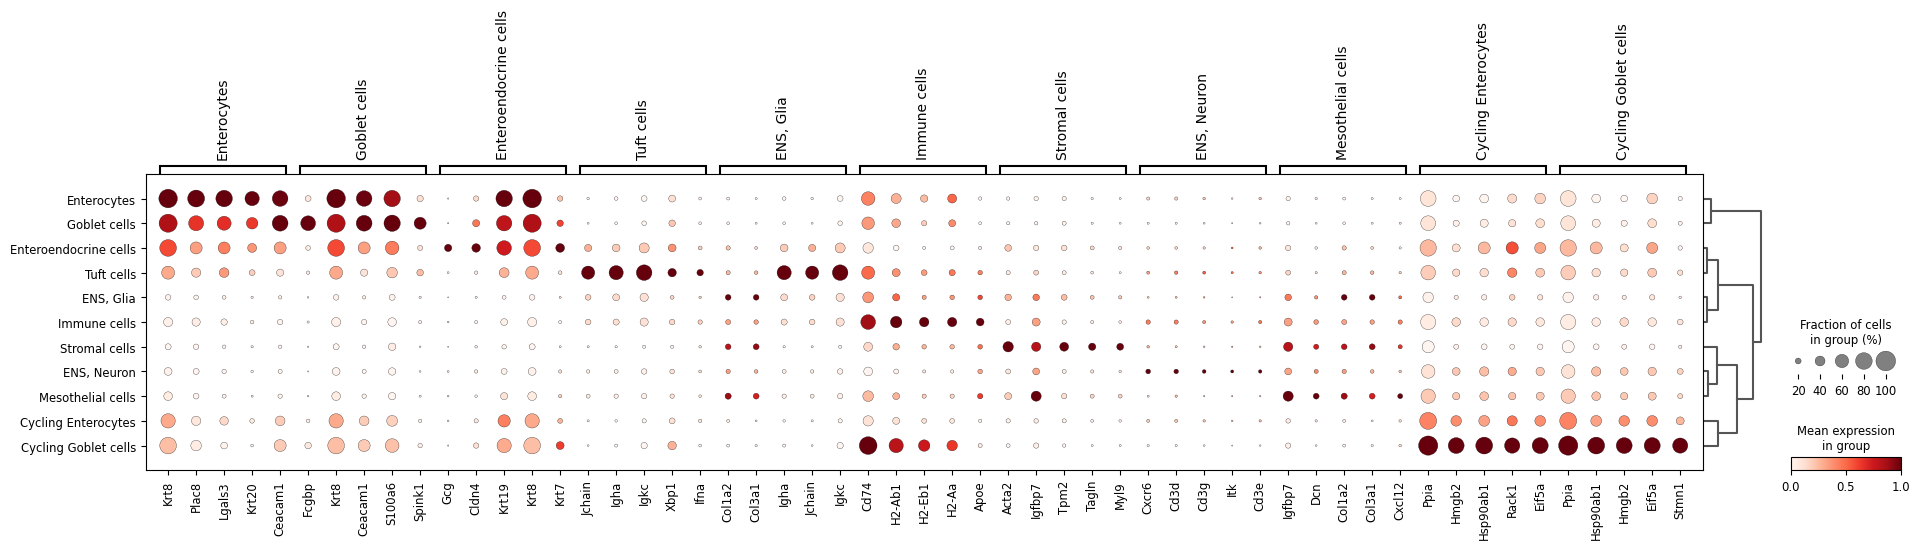

In [32]:
sc.tl.rank_genes_groups(sdata, 
                        layer = 'norm',
                        groupby = 'epi_harmonized_annot', 
                        method = 't-test',
                        pts = True)

sc.tl.dendrogram(sdata, groupby = 'epi_harmonized_annot')
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    layer = 'norm',
    groupby = 'epi_harmonized_annot',
    standard_scale = "var", 
    n_genes = 5,
    #save = query_key + '_' + atlas_key + '_' + scvi_label + '_top-markers_epi.pdf'
)

categories: Cycling Enterocytes, Cycling Goblet cells, ENS, Glia, etc.
var_group_labels: Proliferation, Pan-epithelial, (Cycling) Enterocytes, etc.


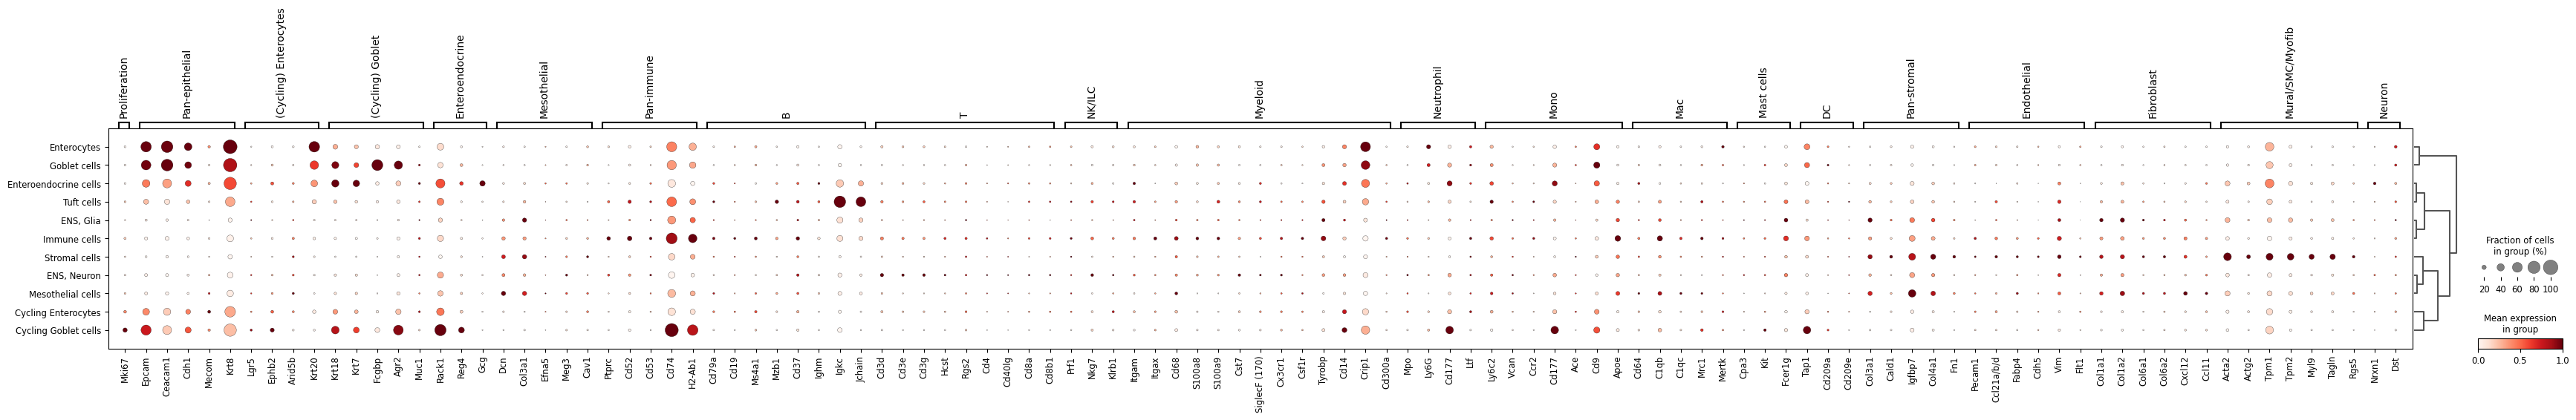

In [33]:
sc.pl.rank_genes_groups_dotplot(
    sdata, 
    var_names = marker_genes_dict,
    layer = 'norm',
    groupby = 'epi_harmonized_annot',
    standard_scale = "var"
    #save = query_key + '_' + atlas_key + '_' + scvi_label + '_known-markers_epi.pdf'
)

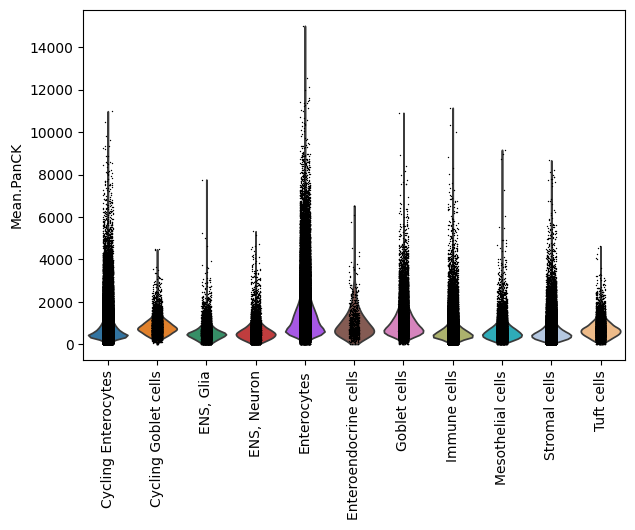

In [34]:
sc.pl.violin(sdata, 
             keys=['Mean.PanCK'], 
             groupby='epi_harmonized_annot', 
             rotation=90)

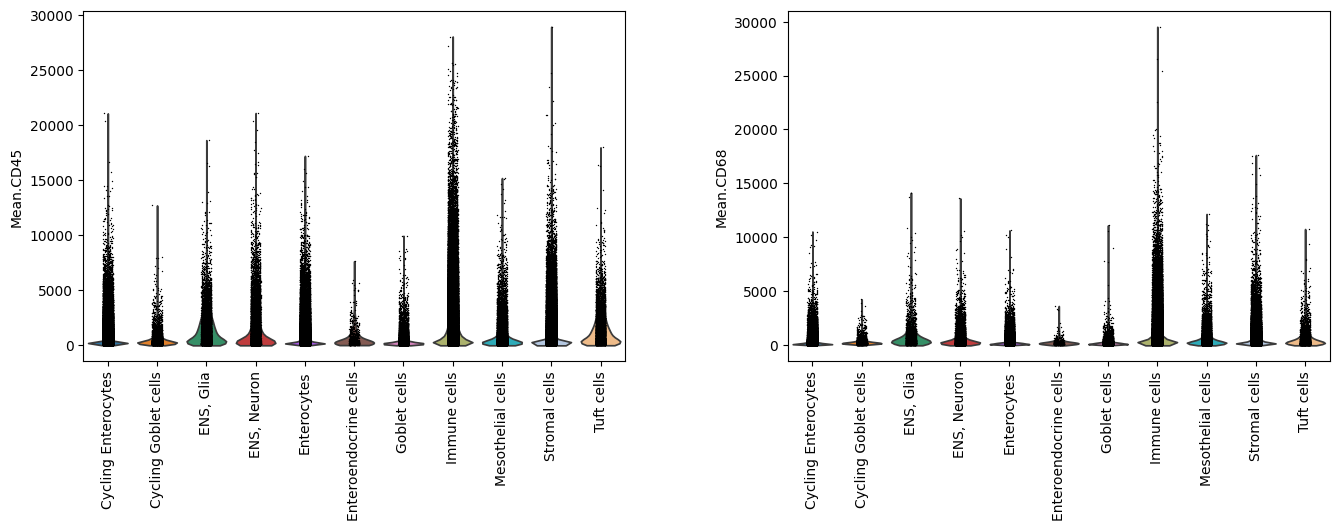

In [35]:
sc.pl.violin(sdata, 
             keys=['Mean.CD45', 'Mean.CD68'], 
             groupby='epi_harmonized_annot', 
             rotation=90)

In [36]:
# Next, we will look at cell composition and spatial distribution